In [2]:
# Librerías para visión artificial
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Cargando el modelo preentrenado
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_alt.xml")

In [4]:
cv2.data.haarcascades

'/home/usr-lbr-maq20/anaconda3/envs/diplomado_rna_ml/lib/python3.11/site-packages/cv2/data/'

In [5]:
!ls /home/usr-lbr-maq20/anaconda3/envs/diplomado_rna_ml/lib/python3.11/site-packages/cv2/data/

haarcascade_eye_tree_eyeglasses.xml
haarcascade_eye.xml
haarcascade_frontalcatface_extended.xml
haarcascade_frontalcatface.xml
haarcascade_frontalface_alt2.xml
haarcascade_frontalface_alt_tree.xml
haarcascade_frontalface_alt.xml
haarcascade_frontalface_default.xml
haarcascade_fullbody.xml
haarcascade_lefteye_2splits.xml
haarcascade_license_plate_rus_16stages.xml
haarcascade_lowerbody.xml
haarcascade_profileface.xml
haarcascade_righteye_2splits.xml
haarcascade_russian_plate_number.xml
haarcascade_smile.xml
haarcascade_upperbody.xml
__init__.py
__pycache__


In [ ]:
#from google.colab import drive #Este bloque e para cargarlo desde google colab
#drive.mount('/content/drive')

Mounted at /content/drive


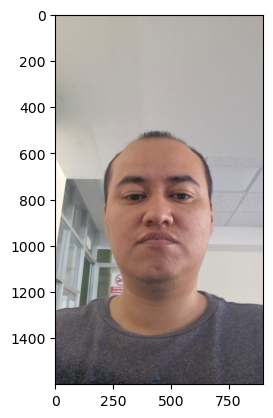

In [ ]:
# Lectura de la imagen
ruta = '/home/usr-lbr-maq20/Documentos/Diplomado-RNA/Modulo-3/Material/Rostros/' #Trataremos de usar la ruta relativa para que no haya problemas al cargar las imagenes
img = cv2.imread(ruta + 'fybr_2.jpeg')

# Conversión de formato
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img, cmap = "Accent")
plt.show()

In [37]:
# Detección de rostros
rostros = face_cascade.detectMultiScale(img, 1.3, 3) # Parámetros: imagen, escala, vecinos
print(rostros)

[[170 565 559 559]]


## Colocar el cuadro delimitador del rostro

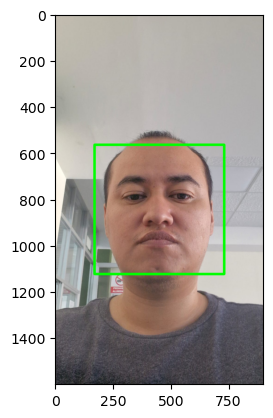

In [38]:
img_copy = np.copy(img)
cv2.rectangle(img_copy, (rostros[0][0],rostros[0][1]), (rostros[0][0]+rostros[0][2],rostros[0][1]+rostros[0][3]), (0,255,0),10)
plt.imshow(img_copy, cmap='Accent')
plt.show()

## Creación de datos de entrenamiento

In [43]:
#  Agregar todas las imagenes de entrenamiento (todas que tengan un _1) que estan en la carpeta Rostros
for i in range(1,22):
    img = cv2.imread(ruta + '**' + str(i) + '.**') # Cargar la imagen con el número i
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rostros = face_cascade.detectMultiScale(img, 1.3, 3)
    


[ WARN:0@2285.569] global loadsave.cpp:278 findDecoder imread_('/home/usr-lbr-maq20/Documentos/Diplomado-RNA/Modulo-3/Material/Rostros/**1.**'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


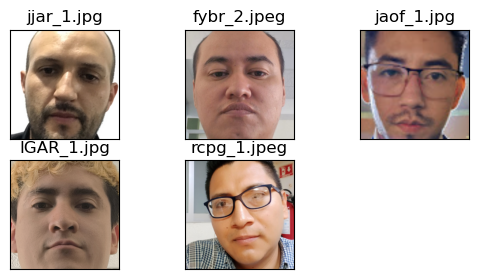

In [ ]:
# Base de entrenamiento con 1 imágen por persona a color
#imagenes = ['jjar_1.jpg','fybr_2.jpeg','jaof_1.jpg', 'IGAR_1.jpg', 'rcpg_1.jpeg'] #Agregar a la lista todas las imagenes de entrenamiento (todas que tengan un _1)
etiquetas = [0,1,2,3,4] #Sabemos que el numero de imagenes totales de entrenamiento son 21
x_train = []
y_train = []
# Deteccion de rostros
for i in range(5):
  img = cv2.imread(ruta+img[i])
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  rostros = face_cascade.detectMultiScale(img, 1.3, 3)
  if len(rostros) > 0:
    x, y, w, h = rostros[0]
    rostro = img[y:y+h, x:x+w, :]
    # Adjuntamos imágen y etiqueta
    rostro = cv2.resize(rostro, (694, 694)) #consideramos un tamaño de 694x694 para todas las imágenes, esto es un hiperparámetro que se puede ajustar
    x_train.append(rostro) #metodo append añade elementos a listas
    y_train.append(etiquetas[i])

    plt.subplot(3,3, i+1, xticks = [], yticks = [])# x e y ticks elimina las reglas del plot
    plt.imshow(rostro, cmap = 'Accent')
    plt.title(imagenes[i])
plt.show()

In [12]:
# Convertimos a arreglos
x_train = np.array(x_train)
y_train = np.array(y_train)

In [13]:
x_train.shape

(5, 694, 694, 3)

In [14]:
# Aplanamos las imágenes
x_train = x_train.reshape(5, 694*694*3)

In [15]:
x_train.shape

(5, 1444908)

## Creación del modelo

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Construcción del clasificador
clasificador = KNeighborsClassifier(n_neighbors=1, p=2) # n_neighbors: número de vecinos a considerar, p: distancia euclidiana
clasificador.fit(x_train, y_train) #.fit() es el método que se utiliza para entrenar el modelo, recibe como parámetros los datos de entrenamiento (x_train) y las etiquetas correspondientes (y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


[[200 490 571 571]]


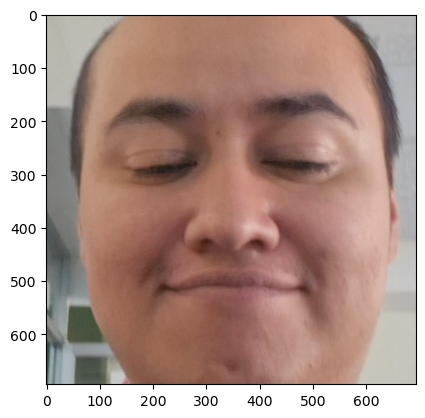

In [ ]:
# Prueba del modelo
imgTest = cv2.imread(ruta+'fybr_1.jpeg')
# Conversión de formato
imgTest = cv2.cvtColor(imgTest, cv2.COLOR_BGR2RGB)
# Detección de rostros
rostro = face_cascade.detectMultiScale(imgTest, 1.3, 3)
print(rostro)
# Selección del rostro
for (x, y, w, h) in rostro:
  rostroTest = imgTest[y:y+h, x:x+w, :]
  rostroTest = cv2.resize(rostroTest, (694,694))
plt.imshow(rostroTest, cmap = 'Accent')
plt.show()


In [20]:
# Clasificación
persona = clasificador.predict(rostroTest.reshape(1, 694*694*3))
print('El rostro pertenece a: ', imagenes[persona[0]])

El rostro pertenece a:  fybr_2.jpeg


Tenemos que generar prueba de inferencia con almenos 10 imagenes 

imagen con su respectiva etiqueta, que corresponda a cada persona, ya sea moviendo ya se los parametros ya sea distancia, oh # de vecinos, incluso el clasificador,